In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax.numpy as jnp
from sklearn.cluster import DBSCAN
from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation, FFMpegWriter

In [344]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob, os
import SFI
import SFI.OLI_bases
import jax.numpy as jnp
from jax import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import pickle
from scipy.spatial.distance import jensenshannon
import csv

def get_experimentID_fightbouts(path):

    tracking_folder = os.path.dirname(path)

    loadpaths = glob.glob(os.path.join(tracking_folder, "*results.h5"))
    loadpaths.sort()

    expNames = [os.path.basename(p)[:23] for p in loadpaths]

    target_expName = os.path.basename(path)[:23]
    expIdx = expNames.index(target_expName)

    fightbout_path = os.path.join(tracking_folder, "fightBouts.h5")

    with h5py.File(fightbout_path, "r") as j:
        fb = j["fight_bout_info_noDurThresh"][:]

    fightbouts = fb[fb[:, 0].astype(int) == expIdx]


    return expIdx, fightbouts
#EXP_id , fightbout = get_experimentID_fightbouts( "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200213_154940_tracking_results.h5")

def prepare_data(path,fightnumber = 0,infight =True):
    "Prepare the data make it ready to calculate dpp,theta1 and theta2"
    "if infight = True return data with only the frist infight bouts otherwise it returns total trajectory  "

    path = path
    f = h5py.File(path, "r")

    X = f["tracks_3D_smooth"][:]
    EXP_id , fightbout = get_experimentID_fightbouts(path)
    if infight == True and fightbout.size > 0:
        X_coordinates = X[fightbout[fightnumber,1]:fightbout[fightnumber,2],:,:,:]
    else:
        X_coordinates = X.copy()
    return X_coordinates,fightbout[fightnumber], EXP_id


def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def calculate_theta(fish0,fish1):
    vector_fish0 = (fish0[:,0,:] - fish0[:,1,:]) # difference in heading of head and pec
    orientation_fish0 = vector_fish0/np.linalg.norm(vector_fish0, axis=1, keepdims=True)

    theta0 = np.arctan2(orientation_fish0[:, 1],  orientation_fish0[:, 0])

    r_01 = fish1[:,1,:] - fish0[:,1,:] 
    phi_01 = np.arctan2(r_01[:,1],r_01[:,0]) #dy,dx

    theta0 = np.arctan2(vector_fish0[:, 1], vector_fish0[:, 0])
    psi_01 = phi_01 - theta0
    psi_01 = wrap_pi(psi_01) # wrap interval from -pi to pi
    return psi_01

def calculate_variables(coordinates_cleaned):
    "input are the coordinates and returns dpp,theta_i and theta_j"

    fish_i = coordinates_cleaned[:,0,:,:]
    fish_j = coordinates_cleaned[:,1,:,:]

    pec_fish_i = coordinates_cleaned[:,0,1,:]
    pec_fish_j = coordinates_cleaned[:,1,1,:]

    d_pp = np.linalg.norm((pec_fish_j-pec_fish_i), axis=1) 
    
    theta_i = calculate_theta(fish_i,fish_j)
    theta_j = calculate_theta(fish_j,fish_i)

    return d_pp, theta_i,theta_j
    
def clean_data(d_pp,theta_i,theta_j):
    mask = (np.isfinite(d_pp) &np.isfinite(theta_i) & np.isfinite(theta_j))
    return d_pp[mask],theta_i[mask],theta_j[mask]


def Build_segmented_data(dpp,theta1,theta2):
    Valid = (np.isfinite(dpp) &np.isfinite(theta1) & np.isfinite(theta2))
    valid_idx = np.where(Valid)[0]

    X_list = []
    time_list = []
    segid_list = []
    seg_ranges = []
    start = 0
    t_offset = 0
    seg_id = 0

    for k in range(1, len(valid_idx) + 1):
        if k == len(valid_idx) or valid_idx[k] != valid_idx[k - 1] + 1: # if there is the end of trajectory or a hole 

            seg_idx = valid_idx[start:k]

            if len(seg_idx) > 5:
                D_seg = dpp[seg_idx]
                th1_seg = np.unwrap(theta1[seg_idx])
                th2_seg = np.unwrap(theta2[seg_idx])

                X_list.append(np.column_stack([D_seg, th1_seg, th2_seg]))
                time_list.append(np.arange(len(seg_idx)) + t_offset)
                segid_list.append(np.full(len(seg_idx), seg_id, dtype=int))
                seg_ranges.append((seg_idx[0], seg_idx[-1]))

                t_offset += len(seg_idx) + 1
                seg_id += 1

            start = k

    X = np.vstack(X_list)
    time_idx = np.concatenate(time_list)
    segment_ids = np.concatenate(segid_list)
    return X, time_idx, segment_ids, seg_ranges

def subsample_random_segments(X, segment_ids, fraction=0.85):
    np.random.seed(5)
    unique_segments = np.unique(segment_ids)
    n_keep = int(fraction * len(unique_segments))
    keep_seg = np.random.choice(unique_segments,size=n_keep,replace= False)

    X_list = []
    time_list = []
    t_offset = 0
    for seg in keep_seg:
        indices = np.where(segment_ids == seg)[0]
        X_seg = X[indices]
        X_list.append(X_seg)
        time_list.append(np.arange(len(X_seg)) + t_offset)
        t_offset += len(X_seg) + 1

    X_new = np.vstack(X_list)
    time_idx_new = np.concatenate(time_list)
    return X_new, time_idx_new

def js_score(real, sim, bins, range_):
    hist_real, bin_edges = np.histogram(real, bins=bins, range=range_)
    hist_sim, _ = np.histogram(sim, bins=bin_edges, range=range_)

    p = hist_real / np.sum(hist_real)
    q = hist_sim / np.sum(hist_sim)

    return jensenshannon(p, q)

def average_js_score(real_dpp, real_t1, real_t2, traj_sim):
    score_dpp = js_score(real_dpp, np.array(traj_sim[:, 0]), bins=50, range_=(0, 20))
    score_t1  = js_score(real_t1,  np.array(traj_sim[:, 1]), bins=50, range_=(-np.pi, np.pi))
    score_t2  = js_score(real_t2,  np.array(traj_sim[:, 2]), bins=50, range_=(-np.pi, np.pi))
    return (score_dpp + score_t1 + score_t2) / 3

def Run_Force_inference(X,time_idx,K,M,lam):
    traj = SFI.StochasticTrajectoryData(X, time_idx, 0.01)
    poly_1d,poly_describe = SFI.OLI_bases.polynomial_basis(dim=1,order=K)
    fourier1d_F1 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center= jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    fourier1d_F2 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center = jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    
    def radial_basis(D):

        return jnp.exp(-D / lam)#p_exp #jnp.concatenate([p_poly,p_exp])

    def C_func(x):
        D  = x[0]
        th1 = x[1]
        th2 = x[2]

        p  = poly_1d(jnp.array([D]))
        p = radial_basis(D)      
        f1 = fourier1d_F1(jnp.array([th1]))
        f2 = fourier1d_F2(jnp.array([th2]))  
        triple = jnp.einsum('i,j,k->ijk', p, f1[1:], f2[1:]).reshape(-1)
        
        phi = jnp.concatenate([
        p, f1, f2, jnp.outer(p, f1[1:]).reshape(-1),jnp.outer(f2[1:], f1[1:]).reshape(-1),
        jnp.outer(p, f2[1:]).reshape(-1),triple], axis=0) #,triple
        return phi 
    
    S = SFI.OverdampedLangevinInference(traj)
    S.compute_diffusion_constant(method="MSD")
    (funcs_and_grad, descriptor) = SFI.OLI_bases.basis_selector(
        {"type": "custom_scalar", "functions": C_func},
        dimension=3,
        output="vector"
    )
  
    basis_F, grad_F = funcs_and_grad
    S.infer_force_linear(basis_linear=basis_F, basis_linear_gradient=grad_F)
    #S.sparsify_force()
    S.compute_force_error() 
    S.print_report()
    return S, descriptor

def endpoint_clustering(all_endpoints):
    D_values = np.unique(all_endpoints[:,0])
    clustered_all = []

    for D in D_values:
        pts = all_endpoints[all_endpoints[:,0] == D]
        
        rounded = np.round(pts[:,1:], 3)
        unique_angles = np.unique(rounded, axis=0)
        
        clustered = np.column_stack([np.full(len(unique_angles), D), unique_angles])
        clustered_all.append(clustered)

    clustered_all = np.vstack(clustered_all)
    return clustered_all

def cluster_endpoints_3d(all_endpoints, decimals=3):
    rounded = np.round(all_endpoints, decimals=decimals)
    clustered = np.unique(rounded, axis=0)
    return clustered

def Simulation_deterministic(S,x0,dt,N_steps,force_tol,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else jnp.clip(x[0], 0.0, 20.0))
        x = x.at[1].set(theta1 if theta1 is not None else wrap_pi(x[1]))
        x = x.at[2].set(theta2 if theta2 is not None else wrap_pi(x[2]))

        if early_stop:
            force_norm = np.linalg.norm(np.array(S.force_ansatz(x[None, :])[0]))

            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break
    return jnp.stack(xs), (step+1)

def Find_endpoints(S_model,outdir,tag="model",save_last_n= 3000):
    accept_rate = []
    all_endpoints =[]
    startpoints = []
    all_forces = []
    last_trajs = []
    D_values = np.linspace(1, 8, 15)
    length = np.linspace(-np.pi, np.pi, 10,endpoint = False)

    outpath = os.path.join(outdir, f"Endpoints_{tag}.csv")

    accepted = 0

    with open(outpath, "w", newline="") as f:
        writer = csv.writer(f)

        # write header
        writer.writerow(["model",
            "d0", "theta10", "theta20",
            "d_final", "theta1_final", "theta2_final",
            "F_d", "F_theta1", "F_theta2","step_used"
        ])
        for d_sim in D_values:
            for theta_i0 in length:
                for theta_j0 in length:
                    x0 = [d_sim, theta_i0, theta_j0]
                    #x0 = [np.random.uniform(1.0,8.0),np.random.uniform(-np.pi,np.pi),np.random.uniform(-np.pi,np.pi)]
                    traj_sim,step = Simulation_deterministic(S_model, x0, dt=0.01, N_steps=5000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)

                    traj_np = np.array(traj_sim)
                    if len(traj_np) >= save_last_n:
                        last_part = traj_np[-save_last_n:]
                    else:
                        # if stopped early fill in 3000 nan values and then last len of traj fill in
                        last_part = np.full((save_last_n, 3), np.nan)
                        last_part[-len(traj_np):] = traj_np

                    last_trajs.append(last_part.astype(np.float32))
                    final_point = traj_np[-1]
                    force = np.array(S_model.force_ansatz(final_point[None, :])[0])
                    
                    all_endpoints.append(final_point)
                    all_forces.append(force)
                    startpoints.append(x0)
                    writer.writerow([
                            tag,x0[0], x0[1], x0[2],
                            final_point[0], final_point[1], final_point[2],
                            force[0], force[1], force[2],step
                        ])
                    f.flush()
                    accepted+=1
    accept_rate.append(accepted / (len(length) * len(length)*len(D_values)))
    if len(all_endpoints) == 0:
        return np.empty((0, 3)), np.empty((0, 3)), np.empty((0, 3)), accept_rate

    all_endpoints = np.array(all_endpoints)
    all_forces = np.array(all_forces)
    startpoints = np.array(startpoints)
    last_trajs = np.array(last_trajs)

    np.savez_compressed(os.path.join(outdir, f"endpoint_{save_last_n}_trajs_{tag}.npz"),last_trajs=last_trajs,startpoints=startpoints,endpoints=all_endpoints)

    return all_endpoints,all_forces,startpoints, accept_rate


def Simulation(S_model,x0,dt,N_steps,key):
    Diffusion = np.array(S_model.diffusion_average)
    L = jnp.linalg.cholesky(Diffusion)
    x = jnp.array(x0)
    xs = []
    for _ in range(N_steps):
        xs.append(x)
        drift = S_model.force_ansatz(x[None, :])[0] 
        key, subkey = random.split(key)
        xi = random.normal(subkey, (3,))

        x = x + drift * dt + jnp.sqrt(2*dt) *  (L @ xi)
        
        x = x.at[0].set(jnp.clip(x[0], 0.0, 35))  
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

    return jnp.stack(xs), key

def make_winner_df(tracking_folder):
    other_info_loadpath = os.path.join(tracking_folder, "winners_losers_inconclusive.h5")

    with h5py.File(other_info_loadpath, "r") as hf:
        winner_idxs = np.array(hf["winner_idxs"][:])
        conclusive = np.array(hf["conclusive_winner_loser"][:])
        already_established = np.array(hf["already_established_dominance"][:])

    df = pd.DataFrame({
        "EXP_id": np.arange(len(winner_idxs)),
        "winnerIdx": winner_idxs.astype(int),
        "conclusive": conclusive.astype(bool),
        "already_established": already_established.astype(bool),
    })

    df = df[~df["EXP_id"].isin([4, 9, 16, 21])]
    return df


path_2 = "../Data/tracking_results/FishTank20200130_153857_tracking_results.h5"
path_3 ="../Data/tracking_results/FishTank20200130_181614_tracking_results.h5"
path_5 = "../Data/tracking_results/FishTank20200213_154940_tracking_results.h5"
#path_7 = "Data/tracking_results/FishTank20200217_160052_tracking_results.h5"
path_8 = "../Data/tracking_results/FishTank20200218_153008_tracking_results.h5"
path_10 = "../Data/tracking_results/FishTank20200327_154737_tracking_results.h5"
path_12 = "../Data/tracking_results/FishTank20200331_162136_tracking_results.h5"
path_13 ="../Data/tracking_results/FishTank20200520_152810_tracking_results.h5"
path_15 = "../Data/tracking_results/FishTank20200525_161602_tracking_results.h5"
path_18 = "../Data/tracking_results/FishTank20200824_151740_tracking_results.h5"
path_19 = "../Data/tracking_results/FishTank20200828_155504_tracking_results.h5"
path_20 = "../Data/tracking_results/FishTank20200902_160124_tracking_results.h5"

paths = {
    2: path_2,
    3: path_3,
    5: path_5,
    8: path_8,
    10: path_10,
    12: path_12,
    13: path_13,
    15: path_15,
    18: path_18,
    19: path_19,
    20: path_20,
}

tracking_folder = os.path.dirname(path_2)
winner_df = make_winner_df(tracking_folder)

X_list = []
segment_ids_list = []
time_idx_list = []

seg_offset = 0
time_offset = 0

experiments = [2,3,5,8,10,12,13,15,18,19,20]
all_first =[]
for exp in experiments:
    path = paths[exp]
    X_coordinates, fightbout ,exp_id= prepare_data(path,0,True)
    
    winner_row = winner_df[winner_df["EXP_id"] == exp_id]
    id_winner = int(winner_row["winnerIdx"].iloc[0])
    if id_winner==1:
        X_coordinates = X_coordinates[:,[1,0],:,:] #put in order [1,0] instead of [0,1]
    
    dpp, theta1, theta2 = calculate_variables(X_coordinates)

    X_seg, time_idx_seg, segment_ids_seg, seg_ranges = Build_segmented_data(dpp,theta1,theta2)
    X_list.append(X_seg)

    segment_ids_list.append(segment_ids_seg + seg_offset)
    time_idx_list.append(time_idx_seg + time_offset)

    seg_offset += segment_ids_seg.max() + 1
    time_offset += time_idx_seg.max() + 1

X_all = np.vstack(X_list)
segment_ids_all = np.concatenate(segment_ids_list)
time_idx_all = np.concatenate(time_idx_list)

dpp = X_all[:,0]
theta1 = wrap_pi(X_all[:,1])
theta2 = wrap_pi(X_all[:,2])
print(dpp.shape)
n = len(X_all)
half = n // 2
X_first = X_all[:half]
X_last  = X_all[half:]
dpp_first,thetha1_first,thetha2_first = X_first[:,0],wrap_pi(X_first[:,1]),wrap_pi(X_first[:,2])
dpp_last,thetha1_last,thetha2_last = X_last[:,0],wrap_pi(X_last[:,1]),wrap_pi(X_last[:,2])

q1, q50, q95 = np.percentile(dpp, [1, 50, 95])
lam_common = jnp.array([q1, q50, q95])
print(lam_common)

print(X_all.shape)
print(segment_ids_all.shape)
print(time_idx_all.shape)

n = int(0.5* len(X_all))
print(n)

X_full,t_full = X_all, time_idx_all
X_first,t_first = X_all[:n],time_idx_all[:n]
X_last,t_last = X_all[n:],time_idx_all[n:]

#S_full, descriptor = Run_Force_inference(X_full, t_full,K=2, M=4,lam=jnp.array([0.77, 2.8, 7.1]))
S_first, descriptor = Run_Force_inference(X_first, t_first,K=3, M=4,lam=lam_common)
S_last, descriptor = Run_Force_inference(X_last, t_last,K=3, M=4,lam=lam_common)


(1040058,)
[0.7804654 2.4657896 9.029227 ]
(1040058, 3)
(1040058,)
(1040058,)
520029
Measurement noise trace: -0.03484136238694191.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.03484136238694191). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[0.5988462  0.00220285 0.00514102]
 [0.00220285 1.1090323  0.29679072]
 [0.00514102 0.29679072 1.1037575 ]]
Measurement noise tensor:
 [[-9.7402465e-03 -8.4360530e-05  4.0390576e-05]
 [-8.4360523e-05 -1.3119377e-02 -2.7796917e-03]
 [ 4.0390561e-05 -2.7796917e-03 -1.1981738e-02]]
Force estimated information: 124146.84375
Force: estimated normalized mean squared error (sampling only): 0.009875376708805561
Force model:
 +26.56 (±0.4835) b₀ -20.51 (±0.1539) b₁ +14.12 (±0.04911) b₂ -5.323 (±0.03363) b₃ -10.18 (±0.06214) b₄ -2.226 (±0.06317) b₅ +0.6611 (±0.0615) b₆ +0.306 (±0.07566) b₇ +0.4024 (±0.0746) b₈ -0.2713 (±0.08013) b₉ -0.007796 (±0.07959) b₁₀ -0.7457 (±0.07497) b₁₁ 

In [346]:
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def analyze_endpoints_file(csv_path, eps=1, min_samples=1):
    df = pd.read_csv(csv_path)

    df = df[df["d_final"] <= 19].copy()

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    X = np.column_stack([
        df["d_final"].values,
        np.cos(df["theta1_final"].values),
        np.sin(df["theta1_final"].values),
        np.cos(df["theta2_final"].values),
        np.sin(df["theta2_final"].values),
    ])

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    df["cluster"] = labels

    return df

def classify_fixed_and_loops(df, eps_loop=1.0, min_samples_loop=1, force_tol=1e-3):
    df = df.copy()

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    fixed = df[df["force_norm"] < force_tol].copy()
    fixed["attractor_type"] = "fixed"
    moving = df[df["force_norm"] >= force_tol].copy()
    moving["attractor_type"] = "loop_or_moving"

    X_fixed = np.column_stack([
        fixed["d_final"].values,
        np.cos(fixed["theta1_final"].values),
        np.sin(fixed["theta1_final"].values),
        np.cos(fixed["theta2_final"].values),
        np.sin(fixed["theta2_final"].values),
    ])
    
    if len(fixed) > 0:
        fixed_labels = DBSCAN(eps=0.3, min_samples=1).fit_predict(X_fixed)
        fixed["attractor_id"] = ["Fixed_" + str(i) for i in fixed_labels]

    X_loop = np.column_stack([
        moving["d_final"].values,
        np.cos(moving["theta1_final"].values),
        np.sin(moving["theta1_final"].values),
        np.cos(moving["theta2_final"].values),
        np.sin(moving["theta2_final"].values),
    ])

    if len(moving) > 0:
        loop_labels = DBSCAN(eps=eps_loop, min_samples=min_samples_loop).fit_predict(X_loop)
        moving["attractor_id"] = ["Moving_" + str(i) for i in loop_labels]

    return pd.concat([fixed, moving], ignore_index=True)

def draw_two_agents(ax, D, theta1, theta2, title=""):
    ax.clear()

    L_head = 0.79
    L_tail = 1.90

    x1, y1 = 0, 0
    x2, y2 = D, 0

    theta1_abs = wrap_pi(-theta1)
    theta2_abs = wrap_pi(np.pi - theta2)

    d1 = np.array([np.cos(theta1_abs), np.sin(theta1_abs)])
    d2 = np.array([np.cos(theta2_abs), np.sin(theta2_abs)])

    tail1 = np.array([x1, y1]) - L_tail * d1
    tail2 = np.array([x2, y2]) - L_tail * d2

    vec1 = (L_head + L_tail) * d1
    vec2 = (L_head + L_tail) * d2

    ax.arrow(*tail1, *vec1,
             head_width=0.25, head_length=0.35,
             length_includes_head=True, color="blue")

    ax.arrow(*tail2, *vec2,
             head_width=0.25, head_length=0.35,
             length_includes_head=True, color="red")

    ax.scatter([x1, x2], [y1, y2], color=["blue", "red"])
    ax.plot([x1, x2], [y1, y2], "k--", alpha=0.4)

    lim = max(D + 3, 5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def F(D_vals,theta1_vals,theta2_vals,Smodel):
    states = jnp.column_stack([D_vals,theta1_vals, theta2_vals])
    F_vals = Smodel.force_ansatz(states)
    dD_dt = np.array(F_vals[:, 0])
    dth1_dt = np.array(F_vals[:, 1])
    dth2_dt = np.array(F_vals[:, 2])
    return dD_dt,dth1_dt,dth2_dt



df startpoint: [ 1.    -1.257  0.628] | npz match: [ 1.    -1.257  0.628] | dist: 0.0000
df startpoint: [ 1.    -1.257  1.257] | npz match: [ 1.    -1.257  1.257] | dist: 0.0000
df startpoint: [ 1.5   -1.257  0.628] | npz match: [ 1.5   -1.257  0.628] | dist: 0.0000
df startpoint: [ 1.5   -1.257  1.257] | npz match: [ 1.5   -1.257  1.257] | dist: 0.0000
df startpoint: [ 2.    -1.257  1.257] | npz match: [ 2.    -1.257  1.257] | dist: 0.0000


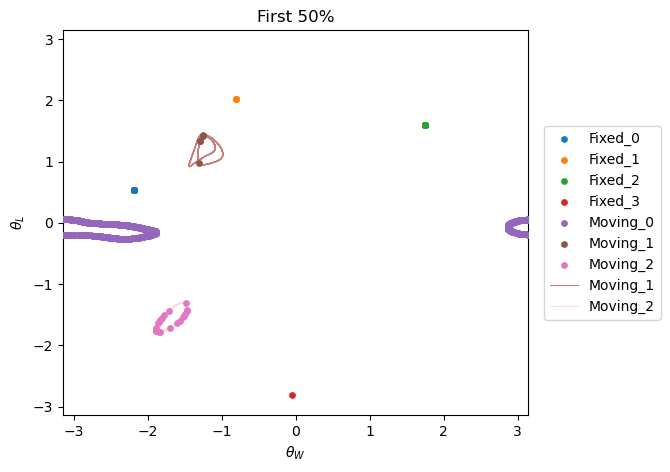

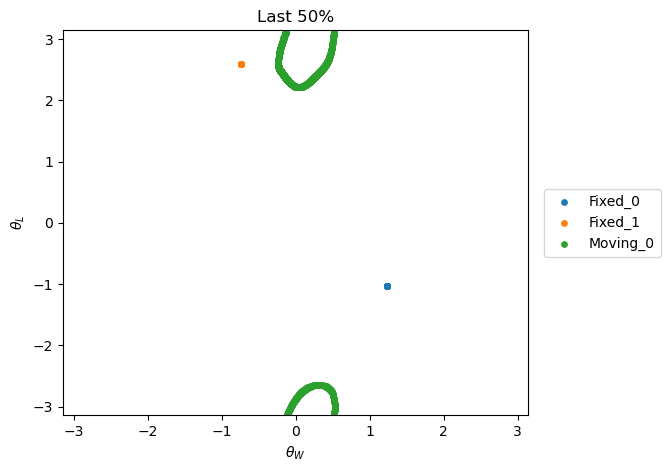

In [332]:

#result_first = analyze_endpoints_file(f"../Results/Exp_{exp_id}_fight1/Endpoints_exp{exp_id}_fight1_first_half.csv")
#result_last = analyze_endpoints_file(f"../Results/Exp_{exp_id}_fight1/Endpoints_exp{exp_id}_fight1_last_half.csv")

## exp 2
exp_id =20
#result_first = analyze_endpoints_file(f"../Results_new/Exp_{exp_id}_fight2/Endpoints_exp{exp_id}_fight1_first_half.csv")
#result_last = analyze_endpoints_file(f"../Results_new/Exp_{exp_id}_fight2/Endpoints_exp{exp_id}_fight1_last_half.csv")

Results_first_all = analyze_endpoints_file(f"../Results_new/All_fightbouts_ordered/Endpoints_first_half.csv")
Results_last_all = analyze_endpoints_file(f"../Results_new/All_fightbouts_ordered/Endpoints_last_half.csv")

classified_first = classify_fixed_and_loops(Results_first_all,eps_loop=1.0,min_samples_loop=1,force_tol=1e-3)
classified_last = classify_fixed_and_loops(Results_last_all,eps_loop=1.0,min_samples_loop=1,force_tol=1e-3)
classified_first.to_csv(f'../Results_new/All_fightbouts_ordered/Classified_first.csv')
classified_last.to_csv(f'../Results_new/All_fightbouts_ordered/Classified_last.csv')

data = np.load("../Results_new/All_fightbouts_ordered/endpoint_3000_trajs_first_half.npz")
last_trajs = data["last_trajs"]    
startpoints = data["startpoints"]    
endpoints = data["endpoints"]     

df = classify_fixed_and_loops(analyze_endpoints_file(f"../Results_new/All_fightbouts_ordered/Endpoints_first_half.csv"))
df = df.reset_index(drop=True)

moving1_df = df[df["attractor_id"] == "Moving_1"].reset_index(drop=True)
matched_indices = []
for _, row in moving1_df.iterrows():
    sp = np.array([row["d0"], row["theta10"], row["theta20"]])
    dists = np.linalg.norm(startpoints - sp, axis=1)
    best = np.argmin(dists)
    print(f"df startpoint: {np.round(sp,3)} | npz match: {np.round(startpoints[best],3)} | dist: {dists[best]:.4f}")
    matched_indices.append(best)
fig, ax = plt.subplots(figsize=(6, 5))

for name, g in classified_first.groupby("attractor_id"):
    ax.scatter(g["theta1_final"], g["theta2_final"], s=15, label=name, zorder=3)


target_colors = {"Moving_1": "brown", "Moving_2": "pink"}
for target in ["Moving_1", "Moving_2"]:
    target_df = df[df["attractor_id"] == target].reset_index(drop=True)
    indices = []
    if len(target_df) == 0:
        continue
    row = target_df.iloc[0]
    sp = np.array([row["d0"], row["theta10"], row["theta20"]])
    best = np.argmin(np.linalg.norm(startpoints - sp, axis=1))
    
    traj = last_trajs[best]
    first_valid = np.argmax(np.isfinite(traj[:, 0]))
    t1 = wrap_pi(traj[first_valid:, 1])
    t2 = wrap_pi(traj[first_valid:, 2])
    ax.plot(t1, t2, alpha=0.6, linewidth=0.8, color=target_colors[target], label=target)

ax.set_xlabel(r"$\theta_W$")
ax.set_ylabel(r"$\theta_L$")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_title('First 50%')
fig.savefig(f'../Results_new/All_fightbouts_ordered/Clustered_endpoints_first.png', bbox_inches="tight")

#plt.savefig(f'../Results_new/All_fightbouts_ordered/Clustered_endpoints_first.png', bbox_inches="tight")
plt.show()

#plt.xlabel(r"$\theta_1$")
#plt.ylabel(r"$\theta_2$")
#plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
#plt.xlim(-np.pi,np.pi)
#plt.ylim(-np.pi,np.pi)
#plt.title('First 50%')
#plt.savefig(f'../Results_new/All_fightbouts_ordered/Clustered_endpoints_first.png',bbox_inches="tight")
#plt.show()

plt.figure(figsize=(6,5))

for name, g in classified_last.groupby("attractor_id"):
    plt.scatter(g["theta1_final"], g["theta2_final"], s=15, label=name)

plt.xlabel(r"$\theta_W$")
plt.ylabel(r"$\theta_L$")
plt.xlim(-np.pi,np.pi)
plt.ylim(-np.pi,np.pi)
plt.title('Last 50%')
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig(f'../Results_new/All_fightbouts_ordered/Clustered_endpoints_last.png',bbox_inches="tight")
plt.show()

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_77286/3456645715.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


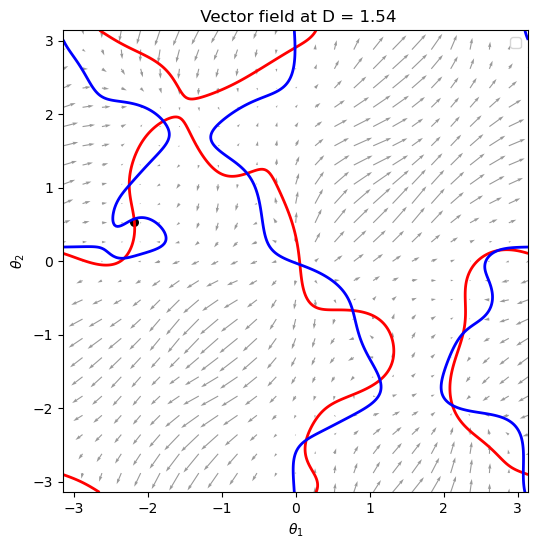

In [366]:
D_value = 1.54
theta_vals = np.linspace(-np.pi, np.pi, 300)
th1, th2 = np.meshgrid(theta_vals, theta_vals)

d_dt, th1_dt, th2_dt = F(
    np.full(th1.size, D_value),
    th1.ravel(),
    th2.ravel(),S_first
)

th1_dt = th1_dt.reshape(th1.shape)
th2_dt = th2_dt.reshape(th2.shape)

theta_vals_q = np.linspace(-np.pi, np.pi, 25)
th1_q, th2_q = np.meshgrid(theta_vals_q, theta_vals_q)

_, th1_dt_q, th2_dt_q = F(np.full(th1_q.size, D_value),th1_q.ravel(),th2_q.ravel(),S_first)

plt.figure(figsize=(6,6))
plt.contour(th1, th2, th1_dt, levels=[0], colors='red', linewidths=2)
plt.contour(th1, th2, th2_dt, levels=[0], colors='blue', linewidths=2)
plt.quiver(th1_q, th2_q, th1_dt_q, th2_dt_q, color='gray', alpha=0.8)
#mask = np.isclose(clustered_all[:, 0], D_value)
#endpoints_D = clustered_all[mask]
#plt.scatter(endpoints_D[:,1], endpoints_D[:,2], c='k', s=30, label='stable endpoints')
plt.scatter(-2.182128   ,   0.531156 , c='k', s=30,)
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(f' Vector field at D = {D_value}')
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.legend()
plt.show()

In [342]:
target = "Moving_1"   # change to "Moving_0", "Moving_2", or "Loop_0" if needed
row = df[df["attractor_id"] == target].iloc[0]
sp = np.array([row["d0"], row["theta10"], row["theta20"]])
best = np.argmin(np.linalg.norm(startpoints - sp, axis=1))

traj = last_trajs[best]
valid = np.isfinite(traj[:, 0])
traj = traj[valid]

D = traj[:, 0]
theta1 = wrap_pi(traj[:, 1])
theta2 = wrap_pi(traj[:, 2])

step = 5
D = D[::step]
theta1 = theta1[::step]
theta2 = theta2[::step]
fig, ax = plt.subplots(figsize=(6, 6))

def update(i):
    draw_two_agents(
        ax,
        D[i],
        theta1[i],
        theta2[i],
        title=f"{target} last 50% | frame {i}/{len(D)-1}\n"
              f"D={D[i]:.2f}, θW={theta1[i]:.2f}, θL={theta2[i]:.2f}"
    )

ani = FuncAnimation(fig, update, frames=len(D), interval=50)

out = "../Results_new/All_fightbouts_ordered/Loop1_first50_config.mp4"
ani.save(out, writer=FFMpegWriter(fps=20, bitrate=1800))

plt.close(fig)

print("saved:", out)

saved: ../Results_new/All_fightbouts_ordered/Loop1_first50_config.mp4


In [364]:
fixed3 = classified_first[classified_first["attractor_id"] == "Fixed_0"]
print(f"Number of points in Fixed_3: {len(fixed3)}")
print(fixed3[["d_final", "theta1_final", "theta2_final", "force_norm"]])

Number of points in Fixed_3: 63
      d_final  theta1_final  theta2_final  force_norm
0    1.546457     -2.182128      0.531156    0.000884
1    1.546440     -2.182064      0.531467    0.000833
2    1.546469     -2.182071      0.531472    0.000896
3    1.546451     -2.182127      0.531155    0.000903
4    1.546497     -2.182078      0.531471    0.000965
..        ...           ...           ...         ...
121  1.546441     -2.182064      0.531468    0.000838
128  1.546483     -2.182074      0.531472    0.000928
135  1.546492     -2.182077      0.531473    0.000965
145  1.546459     -2.182068      0.531470    0.000862
148  1.546503     -2.182138      0.531171    0.000795

[63 rows x 4 columns]


1.546457, 1.397839, 2.930836, moving; 3.8, 1.35, 2.0

In [220]:
def summarize_function(df,exp_id,half):
    summary = (df.groupby(["attractor_type", "attractor_id"]).agg(
            n_points=("attractor_id", "size"),
            d_mean=("d_final", "mean"),
            theta1_mean=("theta1_final", "mean"),
            theta2_mean=("theta2_final", "mean"),
            mean_force=("force_norm", "mean"),
            mean_steps=("step_used", "mean"),

            d_std=("d_final", "std"),
            theta1_std=("theta1_final", "std"),
            theta2_std=("theta2_final", "std"),).reset_index())

    summary["attractor_fraction"] = (summary["n_points"] / len(df))
    summary["exp_id"] = exp_id
    summary["half"] = half

    return summary


all_sumaries = []
exp_runagain = [7,8,13]
exp_ids = [2,3,5,10,12,15,18,19,20]


for exp_id in exp_ids:
    first_path = f"../Results_new/Exp_{exp_id}_fight2/Classified_first.csv"
    last_path  = f"../Results_new/Exp_{exp_id}_fight2/Classified_last.csv"
    df_first = pd.read_csv(first_path)
    df_last = pd.read_csv(last_path)

    summary_first = summarize_function(df_first,exp_id,"first")
    summary_last = summarize_function(df_last,exp_id,"last")
    all_sumaries.append(summary_first)
    all_sumaries.append(summary_last)

for exp_id1 in exp_runagain:
    first_path = f"../Results/Exp_{exp_id1}_fight1/Classified_first.csv"
    last_path  = f"../Results/Exp_{exp_id1}_fight1/Classified_last.csv"
    df_first = pd.read_csv(first_path)
    df_last = pd.read_csv(last_path)

    summary_first = summarize_function(df_first,exp_id1,"first")
    summary_last = summarize_function(df_last,exp_id1,"last")
    all_sumaries.append(summary_first)
    all_sumaries.append(summary_last)

complete_summary = pd.concat(all_sumaries, ignore_index=True)
complete_summary.to_csv("../Results_new/complete_attractor_summary.csv",index = False)

In [221]:
summary_df = pd.read_csv("../Results_new/complete_attractor_summ.csv")
print(summary_df.head(3))


  attractor_type attractor_id  n_points    d_mean  theta1_mean  theta2_mean  \
0          fixed      Fixed_0      1408  2.509541     2.770609     0.089730   
1          fixed      Fixed_1         8  7.673016    -2.809160     0.139837   
2          fixed      Fixed_2        35  4.708411    -2.728564     0.058398   

   mean_force   mean_steps     d_std  theta1_std  theta2_std  \
0    0.000648  1772.529830  0.000102    0.000041    0.000004   
1    0.000870  1702.500000  0.000964    0.000045    0.000058   
2    0.000576   530.857143  0.000138    0.000028    0.000006   

   attractor_fraction  exp_id   half  
0            0.939920       2  first  
1            0.005340       2  first  
2            0.023364       2  first  


In [223]:
dominant_first = summary_df[(summary_df["attractor_fraction"]>0.) &(complete_summary["attractor_type"] == "loop_or_moving")& (summary_df["half"]=="first")]
dominant_last = summary_df[(summary_df["attractor_fraction"]>0.) & (complete_summary["attractor_type"] == "loop_or_moving")&(summary_df["half"]=="last")]
print(dominant_first.shape,dominant_last.shape)

(42, 14) (31, 14)


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_77286/3671552369.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dominant_first = summary_df[(summary_df["attractor_fraction"]>0.) &(complete_summary["attractor_type"] == "loop_or_moving")& (summary_df["half"]=="first")]
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_77286/3671552369.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dominant_last = summary_df[(summary_df["attractor_fraction"]>0.) & (complete_summary["attractor_type"] == "loop_or_moving")&(summary_df["half"]=="last")]


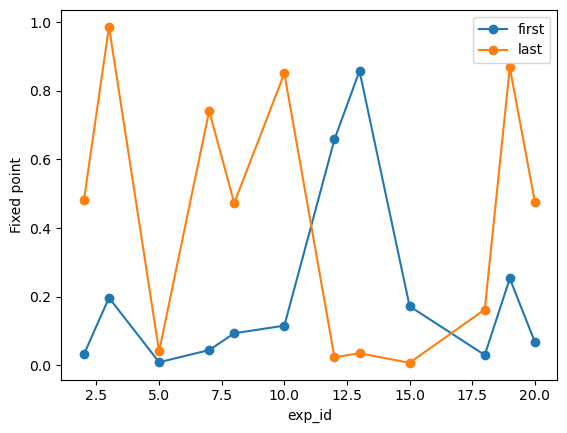

In [208]:
df = summary_df[(summary_df["attractor_fraction"] > 0.0) &(summary_df["attractor_type"] == "loop_or_moving")]
first = (df[df["half"] == "first"].groupby("exp_id")["attractor_fraction"].sum().sort_index())
last = (df[df["half"] == "last"].groupby("exp_id")["attractor_fraction"].sum().sort_index())
plt.plot(first.index, first.values, label="first",marker = "o")
plt.plot(last.index, last.values, label="last",marker = "o")
plt.xlabel("exp_id")
plt.ylabel("Fixed point")
plt.legend()
plt.show()

total first = 110
total last  = 102


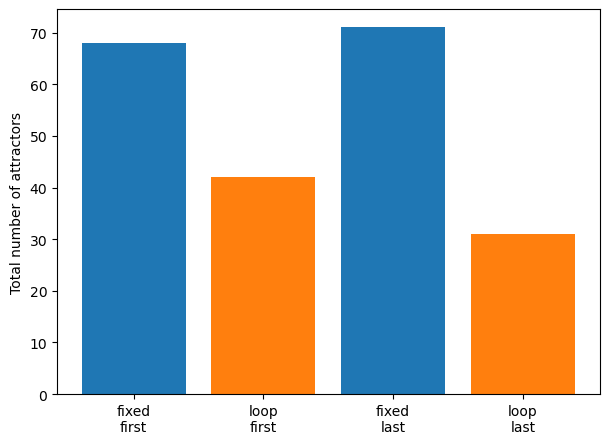

In [236]:
counts = (
    summary_df
    .groupby(["half", "attractor_type"])
    .size()
)

fixed_first = counts.get(("first", "fixed"), 0)
loop_first  = counts.get(("first", "loop_or_moving"), 0)

fixed_last = counts.get(("last", "fixed"), 0)
loop_last  = counts.get(("last", "loop_or_moving"), 0)

plt.figure(figsize=(7,5))

plt.bar(
    ["fixed\nfirst", "loop\nfirst",
     "fixed\nlast", "loop\nlast"],
    
    [fixed_first, loop_first,
     fixed_last, loop_last],

    color=[
        "tab:blue",
        "tab:orange",
        "tab:blue",
        "tab:orange"
    ]
)

plt.ylabel("Total number of attractors")

plt.savefig("../Results_new/Figures/Total_num_attractors_hist.png")

print("total first =", fixed_first + loop_first)
print("total last  =", fixed_last + loop_last)

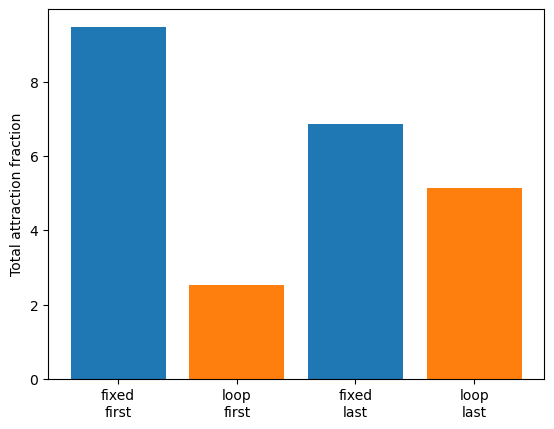

In [237]:
fixed = summary_df[summary_df["attractor_type"]=="fixed"]
loops = summary_df[summary_df["attractor_type"]=="loop_or_moving"]

fixed_first = fixed[fixed["half"]=="first"]["attractor_fraction"].sum()
fixed_last  = fixed[fixed["half"]=="last"]["attractor_fraction"].sum()

loop_first = loops[loops["half"]=="first"]["attractor_fraction"].sum()
loop_last  = loops[loops["half"]=="last"]["attractor_fraction"].sum()

labels = ["fixed\nfirst", "loop\nfirst",
          "fixed\nlast", "loop\nlast"]

values = [
    fixed_first,
    loop_first,
    fixed_last,
    loop_last
]

colors = [
    "tab:blue",   # fixed
    "tab:orange", # loop
    "tab:blue",   # fixed
    "tab:orange"  # loop
]

plt.bar(labels, values, color=colors)

plt.ylabel("Total attraction fraction")

plt.savefig("../Results_new/Figures/Total_attractors_frac_hist.png")


In [217]:
summary_df.groupby(["half","attractor_type"])["attractor_fraction"].mean()

half   attractor_type
first  fixed             0.139329
       loop_or_moving    0.060134
last   fixed             0.096541
       loop_or_moving    0.165988
Name: attractor_fraction, dtype: float64

In [238]:
def Simulation_deterministic(S,x0,dt,N_steps,force_tol,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else jnp.clip(x[0], 0.0, 20.0))
        x = x.at[1].set(theta1 if theta1 is not None else wrap_pi(x[1]))
        x = x.at[2].set(theta2 if theta2 is not None else wrap_pi(x[2]))

        if early_stop:
            force_norm = np.linalg.norm(np.array(S.force_ansatz(x[None, :])[0]))

            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break
    return jnp.stack(xs)